<div style="
    text-align: center; 
    background: linear-gradient(135deg, #0062ff 0%, #00d4ff 100%); 
    font-family: 'Segoe UI', Roboto, Helvetica, Arial, sans-serif; 
    color: white; 
    padding: 35px 20px; 
    border-radius: 15px; 
    box-shadow: 0 10px 25px rgba(0, 98, 255, 0.3);
    margin-bottom: 25px;">
    <div style="font-size: 35px; font-weight: 800; letter-spacing: 1.5px; text-transform: uppercase; line-height: 1.2;">
        Trực Quan Hóa Dữ Liệu - Lab 01
    </div>
    <div style="font-size: 16px; font-weight: 500; margin-top: 10px; font-style: italic; opacity: 0.9;">
        "Phân tích thị trường mỹ phẩm nội vs ngoại trên Tiki"
    </div>
    <div style="font-size: 18px; font-weight: 600; margin-top: 15px; border-top: 1px solid rgba(255,255,255,0.4); display: inline-block; padding-top: 10px; letter-spacing: 1px;">
        NHÓM 05 - FIT-HCMUS
    </div>
</div>

<div style="text-align: center; font-size: 40px; font-weight: bold;">
  Tổng quan thị trường & Động lực tăng trưởng
</div>

# **1. Thiết lập môi trường và nạp dữ liệu**
## **1.1. Thiết lập môi trường**

In [1]:
# Cài đặt các thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# Thiết lập style toàn cục cho các biểu đồ
plt.rcParams.update({
    'font.family'       : 'DejaVu Sans',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.grid'         : False,
    'grid.alpha'        : 0.25,
    'grid.linestyle'    : '--',
    'figure.dpi'        : 130,
    'savefig.dpi'       : 150,
    'axes.titlesize'    : 14,
    'axes.titleweight'  : 'bold',
    'axes.labelsize'    : 11,
    'xtick.labelsize'   : 10,
    'ytick.labelsize'   : 10,
})

# Bảng màu nhất quán xuyên suốt
C_DOMESTIC = '#2563EB'   # xanh dương — hàng trong nước
C_IMPORT   = '#DC2626'   # đỏ         — hàng ngoài nước
PALETTE    = [C_DOMESTIC, C_IMPORT]
COUNTRY_COLORS = [
    '#EF4444','#F97316','#EAB308','#22C55E','#3B82F6',
    '#8B5CF6','#EC4899','#14B8A6','#F59E0B','#6366F1'
]

print('Các thư viện đã được cài đặt và cấu hình thành công!')

Các thư viện đã được cài đặt và cấu hình thành công!


## **1.2. Nạp dữ liệu**

In [7]:
# 1. Nạp dữ liệu
df = pd.read_csv('../data/tiki_cosmetics_processed.csv')

# 2. Khôi phục thứ tự cho phân khúc giá (để vẽ biểu đồ không bị nhảy lộn xộn)
price_order = ['Dưới 100k', '100k – 300k', '300k – 700k', '700k – 2tr', 'Trên 2tr']
df['price_segment'] = pd.Categorical(df['price_segment'], categories=price_order, ordered=True)

# 3. Tập con theo origin_class_corrected (đã hiệu chỉnh ở file preprocessing)
df_vn = df[df['origin_class_corrected'] == 'Trong nước'].copy()
df_nn = df[df['origin_class_corrected'] == 'Ngoài nước'].copy()

# 4. Kiểm tra các chỉ số (ĐÃ FIX LỖI KHOẢNG TRẮNG)
print(f' Tổng sản phẩm : {len(df):,}')
print(f'    Trong nước : {len(df_vn):,} ({len(df_vn)/len(df)*100:.1f}%)')
print(f'    Ngoài nước : {len(df_nn):,} ({len(df_nn)/len(df)*100:.1f}%)')
print(f'Số thương hiệu : {df["brand_name"].nunique():,}')
print(f'   Số danh mục : {df["category"].nunique()}')
print(f'    Khoảng giá : {df["price"].min():,.0f} – {df["price"].max():,.0f} VNĐ')

df.head(5)

 Tổng sản phẩm : 7,179
    Trong nước : 1,915 (26.7%)
    Ngoài nước : 5,264 (73.3%)
Số thương hiệu : 956
   Số danh mục : 30
    Khoảng giá : 10,000 – 18,000,000 VNĐ


,product_id,name,name_clean,brand_name,seller_name,product_type,category,primary_category,origin_class_corrected,origin_corrected,...,estimated_revenue,is_official_store,is_authentic,has_authentic_badge,tiki_verified,availability,availability_label,sold_hidden_flag,has_name_duplicate,is_extreme_outlier
0,277375294,Sữa rửa mặt dưỡng trắng cao cấp Hada Labo Prem...,Sữa rửa mặt dưỡng trắng cao cấp Hada Labo Prem...,Hada Labo,Tiki Trading,Skincare,Sữa rửa mặt,Sữa rửa mặt,Ngoài nước,Nhật Bản,...,2461000,True,1,True,0,1,Còn hàng,False,False,False
1,277375219,Sữa rửa mặt Hada Labo dưỡng ẩm cao cấp Premium...,Sữa rửa mặt Hada Labo dưỡng ẩm cao cấp Premium...,Hada Labo,Tiki Trading,Skincare,Sữa rửa mặt,Sữa rửa mặt,Ngoài nước,Nhật Bản,...,3069000,True,1,True,0,1,Còn hàng,False,False,False
2,276486487,Sữa Rửa Mặt Rosette Làm Giảm Mụn Face Wash Pas...,Sữa Rửa Mặt Rosette Làm Giảm Mụn Face Wash Pas...,Rosette,Tiki Trading,Skincare,Sữa rửa mặt,Sữa rửa mặt,Ngoài nước,Nhật Bản,...,932400,True,1,True,0,1,Còn hàng,False,False,False
3,276396782,Sữa rửa mặt X-Men 100g Detox/Sáng da/Ngừa mụn/...,Sữa rửa mặt X-Men Detox/Sáng da/Ngừa mụn/Kiểm ...,X-Men,Tiki Trading,Skincare,Sữa rửa mặt,Sữa rửa mặt,Trong nước,Việt Nam,...,1116000,True,1,True,0,1,Còn hàng,False,False,False
4,276022717,"Sữa rửa mặt cho nam Oxy sạch dịu nhẹ, kiềm dầu...","Sữa rửa mặt cho nam Oxy sạch dịu nhẹ, kiềm dầu...",OXY,Tiki Trading,Skincare,Sữa rửa mặt,Sữa rửa mặt,Trong nước,Việt Nam,...,4582000,True,1,True,0,1,Còn hàng,False,False,False


# **2. Phân tích, trực quan hóa dữ liệu và kết luận**
## **2.1. Mục tiêu 1:** Xác định thị phần doanh thu giữa hàng nội và hàng ngoại trên toàn bộ tập dữ liệu để xác định nhóm hàng nắm giữ giá trị giao dịch cao nhất.
### **2.1.1. Lí do chọn mục tiêu**
Trong bối cảnh thị trường mỹ phẩm Việt Nam đang tăng trưởng mạnh, câu hỏi cốt lõi nhất là: **người tiêu dùng đang "chảy tiền" về đâu — hàng nội hay hàng ngoại?** Mục tiêu này tập trung trả lời câu hỏi đó thông qua chỉ số doanh thu ước tính (estimated_revenue = sold_count × price), là thước đo phản ánh trực tiếp hành vi chi tiêu thực tế, không chỉ là số lượng sản phẩm niêm yết.

### **2.1.2. Phân tích và trực quan hóa dữ liệu**
**Hành động cụ thể:** Truy vấn

**Biểu đồ lựa chọn:**
- **Biểu đồ tròn (Pie chart):** phù hợp nhất khi cần trực quan hóa tỉ lệ phần trăm của toàn bộ, giúp lập tức nắm được mức độ chênh lệch áp đảo giữa hai nhóm.
- **Biểu đồ cột ngang (Horizontal bar chart):** phù hợp để so sánh doanh thu giữa nhiều quốc gia vì nhãn tên nước dài, trục ngang giúp dễ đọc hơn trục dọc.
- **Biểu đồ cột nhóm (Grouped bar chart):** phù hợp để so sánh đồng thời doanh thu nội/ngoại trên từng phân khúc giá — thể hiện rõ sự giao thoa hay phân tầng giữa hai nhóm theo mức chi tiêu.

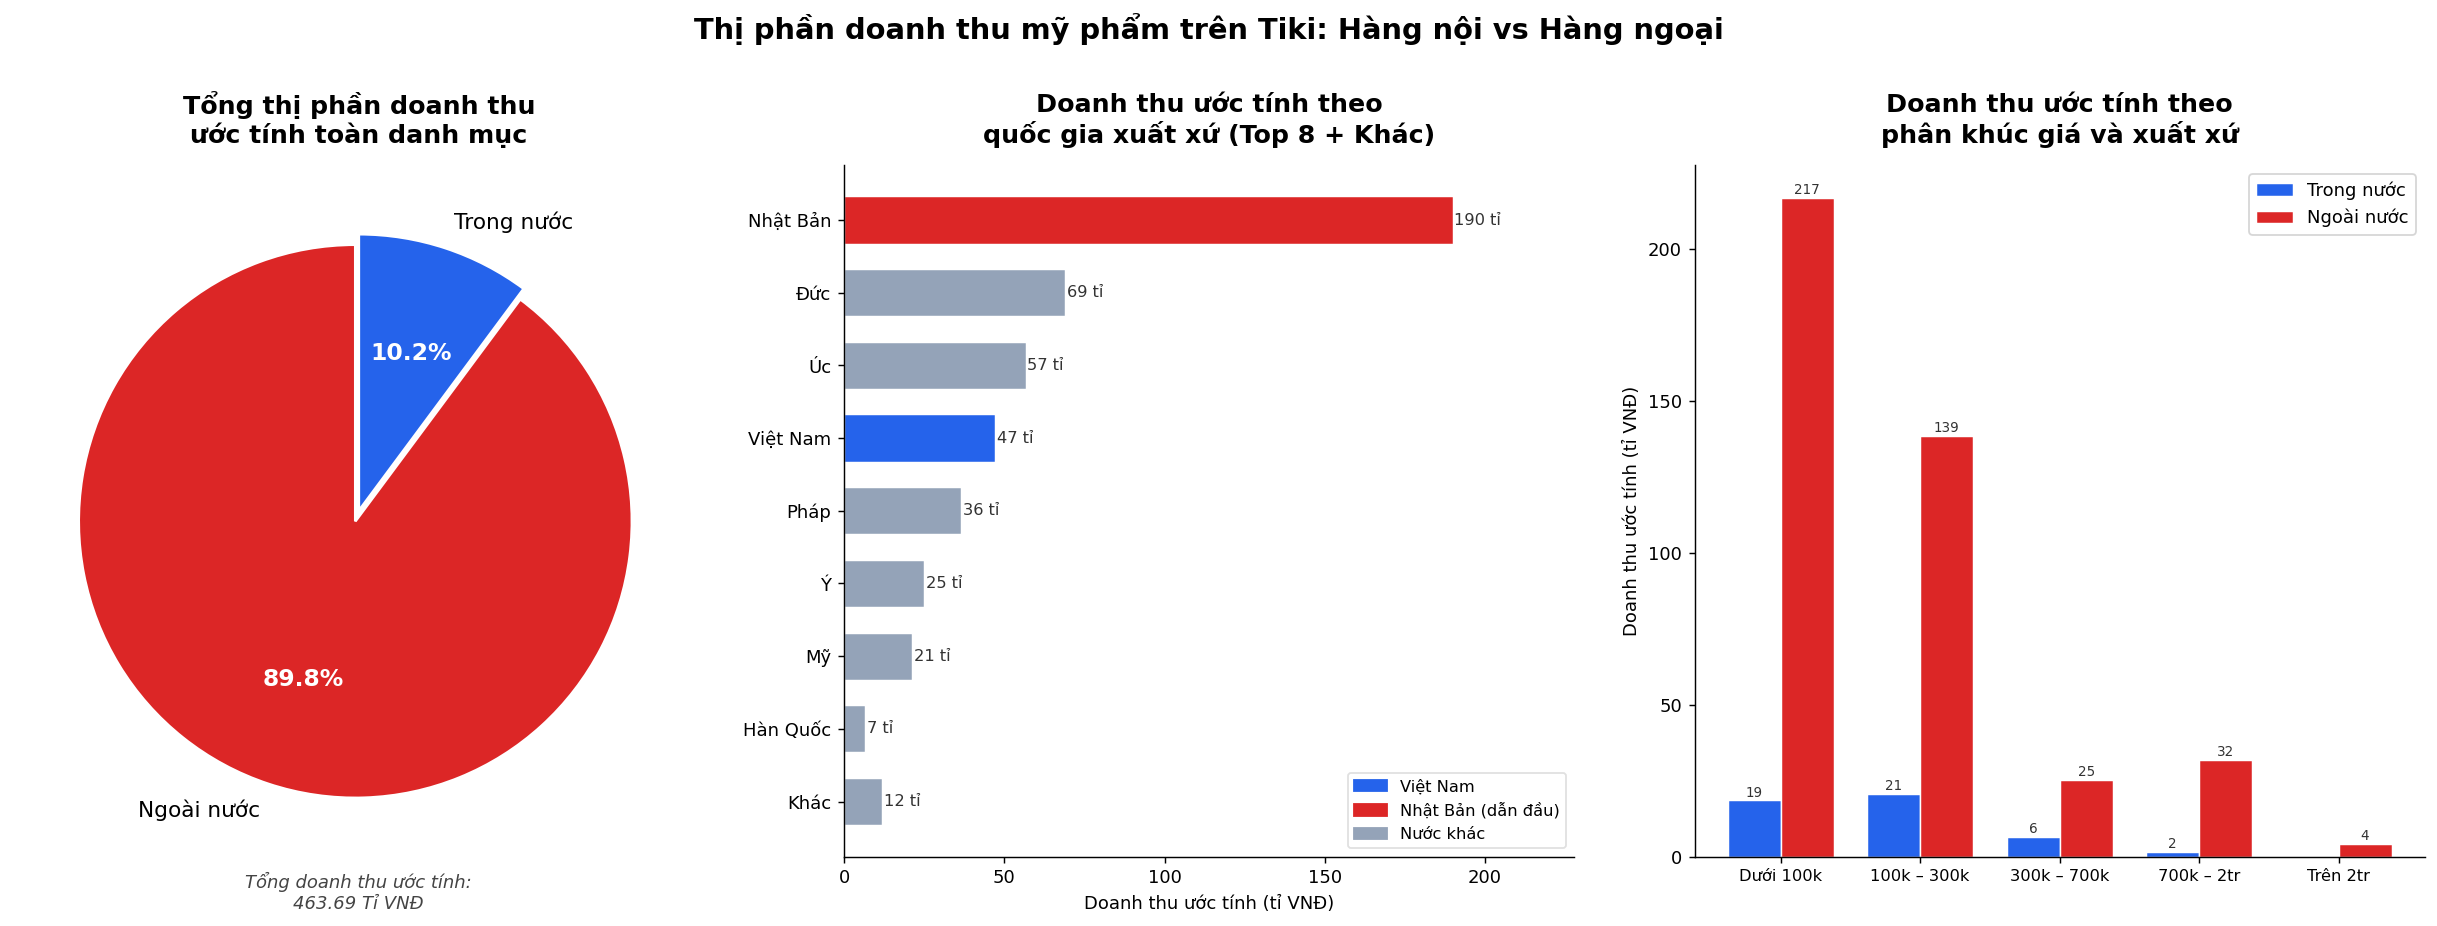

In [9]:
# 1. Chuẩn bị dữ liệu
# Sử dụng cột đã hiệu chỉnh origin_class_corrected, origin_corrected từ bước tiền xử lý (Brand Origin Mapping)
rev_by_origin = (
    df.groupby('origin_class_corrected')['estimated_revenue']
    .sum()
    .sort_values(ascending=False)
)
total_rev = rev_by_origin.sum()

# Doanh thu theo quốc gia — lấy top 8, gom phần còn lại thành "Khác"
rev_by_country_raw = (
    df.groupby('origin_corrected')['estimated_revenue']
    .sum()
    .sort_values(ascending=False)
)
top_n = 8
top_countries = rev_by_country_raw.head(top_n)
others_val    = rev_by_country_raw.iloc[top_n:].sum()
rev_by_country = pd.concat([top_countries, pd.Series({'Khác': others_val})])

# Doanh thu theo phân khúc giá × xuất xứ
price_order = ['Dưới 100k', '100k – 300k', '300k – 700k', '700k – 2tr', 'Trên 2tr']
df['price_segment'] = pd.Categorical(df['price_segment'], categories=price_order, ordered=True)

rev_price_origin = (
    df.groupby(['price_segment', 'origin_class_corrected'], observed=True)['estimated_revenue']
    .sum()
    .unstack(fill_value=0)
    .loc[price_order]           # đảm bảo đúng thứ tự
)

# 2. Vẽ biểu đồ (1×3 layout)
fig, axes = plt.subplots(1, 3, figsize=(19, 7))
fig.suptitle('Thị phần doanh thu mỹ phẩm trên Tiki: Hàng nội vs Hàng ngoại',
             fontsize=16, fontweight='bold', y=1.01)

# Biểu đồ 1: Pie chart tổng thị phần
ax1 = axes[0]
pie_colors   = [C_IMPORT, C_DOMESTIC]
explode_vals = (0.04, 0)        # tách nhẹ miếng "Ngoài nước" để nhấn mạnh

wedges, texts, autotexts = ax1.pie(
    rev_by_origin,
    labels=rev_by_origin.index,
    colors=pie_colors,
    explode=explode_vals,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(linewidth=1.5, edgecolor='white'),
    textprops=dict(fontsize=12),
)
for at in autotexts:
    at.set(fontsize=13, fontweight='bold', color='white')

ax1.set_title('Tổng thị phần doanh thu\nước tính toàn danh mục', pad=12)

# Chú thích tổng doanh thu
total_str = f"Tổng doanh thu ước tính:\n{total_rev/1e9:.2f} Tỉ VNĐ"
ax1.text(0, -1.38, total_str, ha='center', va='center',
         fontsize=10, color='#444', style='italic')

# Biểu đồ 2: Bar chart doanh thu theo quốc gia
ax2 = axes[1]
bar_colors = [C_DOMESTIC if c == 'Việt Nam' else '#94A3B8'
              for c in rev_by_country.index]
# Nổi bật thêm Japan
bar_colors = []
for c in rev_by_country.index:
    if c == 'Việt Nam':
        bar_colors.append(C_DOMESTIC)
    elif c == 'Nhật Bản':
        bar_colors.append(C_IMPORT)
    else:
        bar_colors.append('#94A3B8')

bars = ax2.barh(
    rev_by_country.index[::-1],      # đảo để top ở trên
    rev_by_country.values[::-1] / 1e9,
    color=bar_colors[::-1],
    edgecolor='white', linewidth=0.8,
    height=0.65
)

# Nhãn giá trị bên phải mỗi cột
for bar in bars:
    w = bar.get_width()
    ax2.text(w + 0.5, bar.get_y() + bar.get_height() / 2,
             f'{w:,.0f} tỉ', va='center', ha='left', fontsize=9, color='#333')

ax2.set_xlabel('Doanh thu ước tính (tỉ VNĐ)', fontsize=10)
ax2.set_title('Doanh thu ước tính theo\nquốc gia xuất xứ (Top 8 + Khác)', pad=12)
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax2.set_xlim(0, rev_by_country.max() / 1e9 * 1.2)

# Legend màu
patch_vn  = mpatches.Patch(color=C_DOMESTIC, label='Việt Nam')
patch_jp  = mpatches.Patch(color=C_IMPORT,   label='Nhật Bản (dẫn đầu)')
patch_oth = mpatches.Patch(color='#94A3B8',  label='Nước khác')
ax2.legend(handles=[patch_vn, patch_jp, patch_oth],
           loc='lower right', fontsize=9, framealpha=0.6)

# Biểu đồ 3: Grouped bar — phân khúc giá × xuất xứ
ax3 = axes[2]
x      = np.arange(len(price_order))
width  = 0.38

bars_vn = ax3.bar(x - width/2,
                  rev_price_origin.get('Trong nước', 0) / 1e9,
                  width, label='Trong nước', color=C_DOMESTIC,
                  edgecolor='white', linewidth=0.8)
bars_nn = ax3.bar(x + width/2,
                  rev_price_origin.get('Ngoài nước', 0) / 1e9,
                  width, label='Ngoài nước', color=C_IMPORT,
                  edgecolor='white', linewidth=0.8)

# Nhãn giá trị trên đỉnh cột (chỉ hiện nếu > 0)
def label_bars(bars_group, ax, fmt='{:.0f}'):
    for bar in bars_group:
        h = bar.get_height()
        if h > 0.5:
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.3,
                    fmt.format(h), ha='center', va='bottom',
                    fontsize=7.5, color='#333')

label_bars(bars_vn, ax3)
label_bars(bars_nn, ax3)

ax3.set_xticks(x)
ax3.set_xticklabels(price_order, fontsize=9)
ax3.set_ylabel('Doanh thu ước tính (tỉ VNĐ)', fontsize=10)
ax3.set_title('Doanh thu ước tính theo\nphân khúc giá và xuất xứ', pad=12)
ax3.legend(fontsize=10)
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

### **2.1.3. Nhận xét và kết luận**

**Nhận xét từ biểu đồ:**

① **Thị phần tổng quát (Biểu đồ 1):**
Hàng ngoại chiếm ~**89.8%** tổng doanh thu ước tính, trong khi hàng nội chỉ đóng góp khoảng **10.2%**. Sự chênh lệch áp đảo này cho thấy người tiêu dùng trên Tiki đang chi tiêu chủ yếu cho các thương hiệu quốc tế, dù về số lượng sản phẩm niêm yết, hàng nội chiếm tỉ lệ đáng kể hơn (~26.7%). Điều này hàm ý rằng các sản phẩm ngoại không chỉ nhiều về lượng mà còn có giá trị giao dịch trung bình cao hơn hoặc lượt bán vượt trội hơn đáng kể.

② **Doanh thu theo quốc gia (Biểu đồ 2):**
**Nhật Bản** là quốc gia dẫn đầu tuyệt đối với doanh thu ước tính gần **190 tỉ VNĐ**, gần gấp đôi vị trí thứ hai (Đức). Điều này phản ánh sức hút cực mạnh của các thương hiệu Nhật như Hada Labo, Senka, Sunplay, Acnes trên thị trường. Đáng chú ý, **Đức** và **Úc** lọt top 3 - phần lớn do hiệu ứng cộng dồn của Nivea và Selsun với lượt bán rất cao ở phân khúc giá rẻ. Việt Nam ở vị trí thứ 4, cho thấy dù không cạnh tranh được về quy mô, hàng nội vẫn có chỗ đứng nhất định.

③ **Phân khúc giá (Biểu đồ 3):**
Cả hai nhóm đều tập trung doanh thu ở phân khúc **Dưới 100k** và **100k – 300k**, phản ánh đúng hành vi tiêu dùng mỹ phẩm đại trà tại Việt Nam. Tuy nhiên, ở phân khúc giá thấp (**Dưới 100k**), hàng ngoại vẫn áp đảo - điều bất ngờ vì thông thường hàng nội địa mới được kỳ vọng có lợi thế cạnh tranh về giá. Ở phân khúc **Trên 2tr**, hàng nội gần như vắng bóng, phản ánh định vị thương hiệu chưa đủ mạnh để cạnh tranh ở phân khúc cao cấp.

**Kết luận:**
Mục tiêu phân tích được trả lời rõ ràng: **hàng ngoại nắm giữ phần lớn giá trị giao dịch mỹ phẩm trên Tiki (~89.8%)**, với Nhật Bản là nguồn xuất xứ chiếm ưu thế vượt trội. Thương hiệu nội địa chỉ có lợi thế cạnh tranh đáng kể ở một số danh mục đặc thù (sẽ phân tích sâu ở Mục tiêu 3), chứ chưa có khả năng cạnh tranh toàn diện trên toàn bộ thị trường.

## **2.2. Mục tiêu 2:** Sử dụng ma trận tương quan để nhận diện hai yếu tố tác động mạnh nhất đến lượt bán (Sold Count) của từng phân khúc sản phẩm.
### **2.2.1. Lí do chọn mục tiêu**
Việc biết được *cái gì bán chạy* chưa đủ - điều quan trọng hơn là hiểu **tại sao** một sản phẩm bán chạy. Nếu xác định được các yếu tố tương quan mạnh nhất với lượt bán, nhà bán lẻ và thương hiệu có thể tập trung nguồn lực vào đúng đòn bẩy tăng trưởng. Mục tiêu này tiếp cận câu hỏi đó thông qua phân tích tương quan thống kê, phân tầng theo phân khúc giá để phát hiện liệu các yếu tố ảnh hưởng có thay đổi theo mức giá hay không.
### **2.2.2. Phân tích và trực quan hóa dữ liệu**
**Hành động cụ thể:** Phân tích

**Biểu đồ lựa chọn:**
- **Heatmap tương quan:** biểu đồ chuẩn mực nhất để trực quan hóa ma trận tương quan - màu sắc giúp nhận diện ngay cường độ và hướng của mối quan hệ giữa các cặp biến.
- **Biểu đồ thanh hệ số tương quan (Bar chart):** so sánh trực tiếp độ lớn tương quan của từng yếu tố với sold_count, dễ xác định top 2 yếu tố quan trọng nhất.
- **Strip plot + trendline theo phân khúc:** thể hiện mối quan hệ thực tế giữa hai biến quan trọng nhất với sold_count theo từng phân khúc giá.

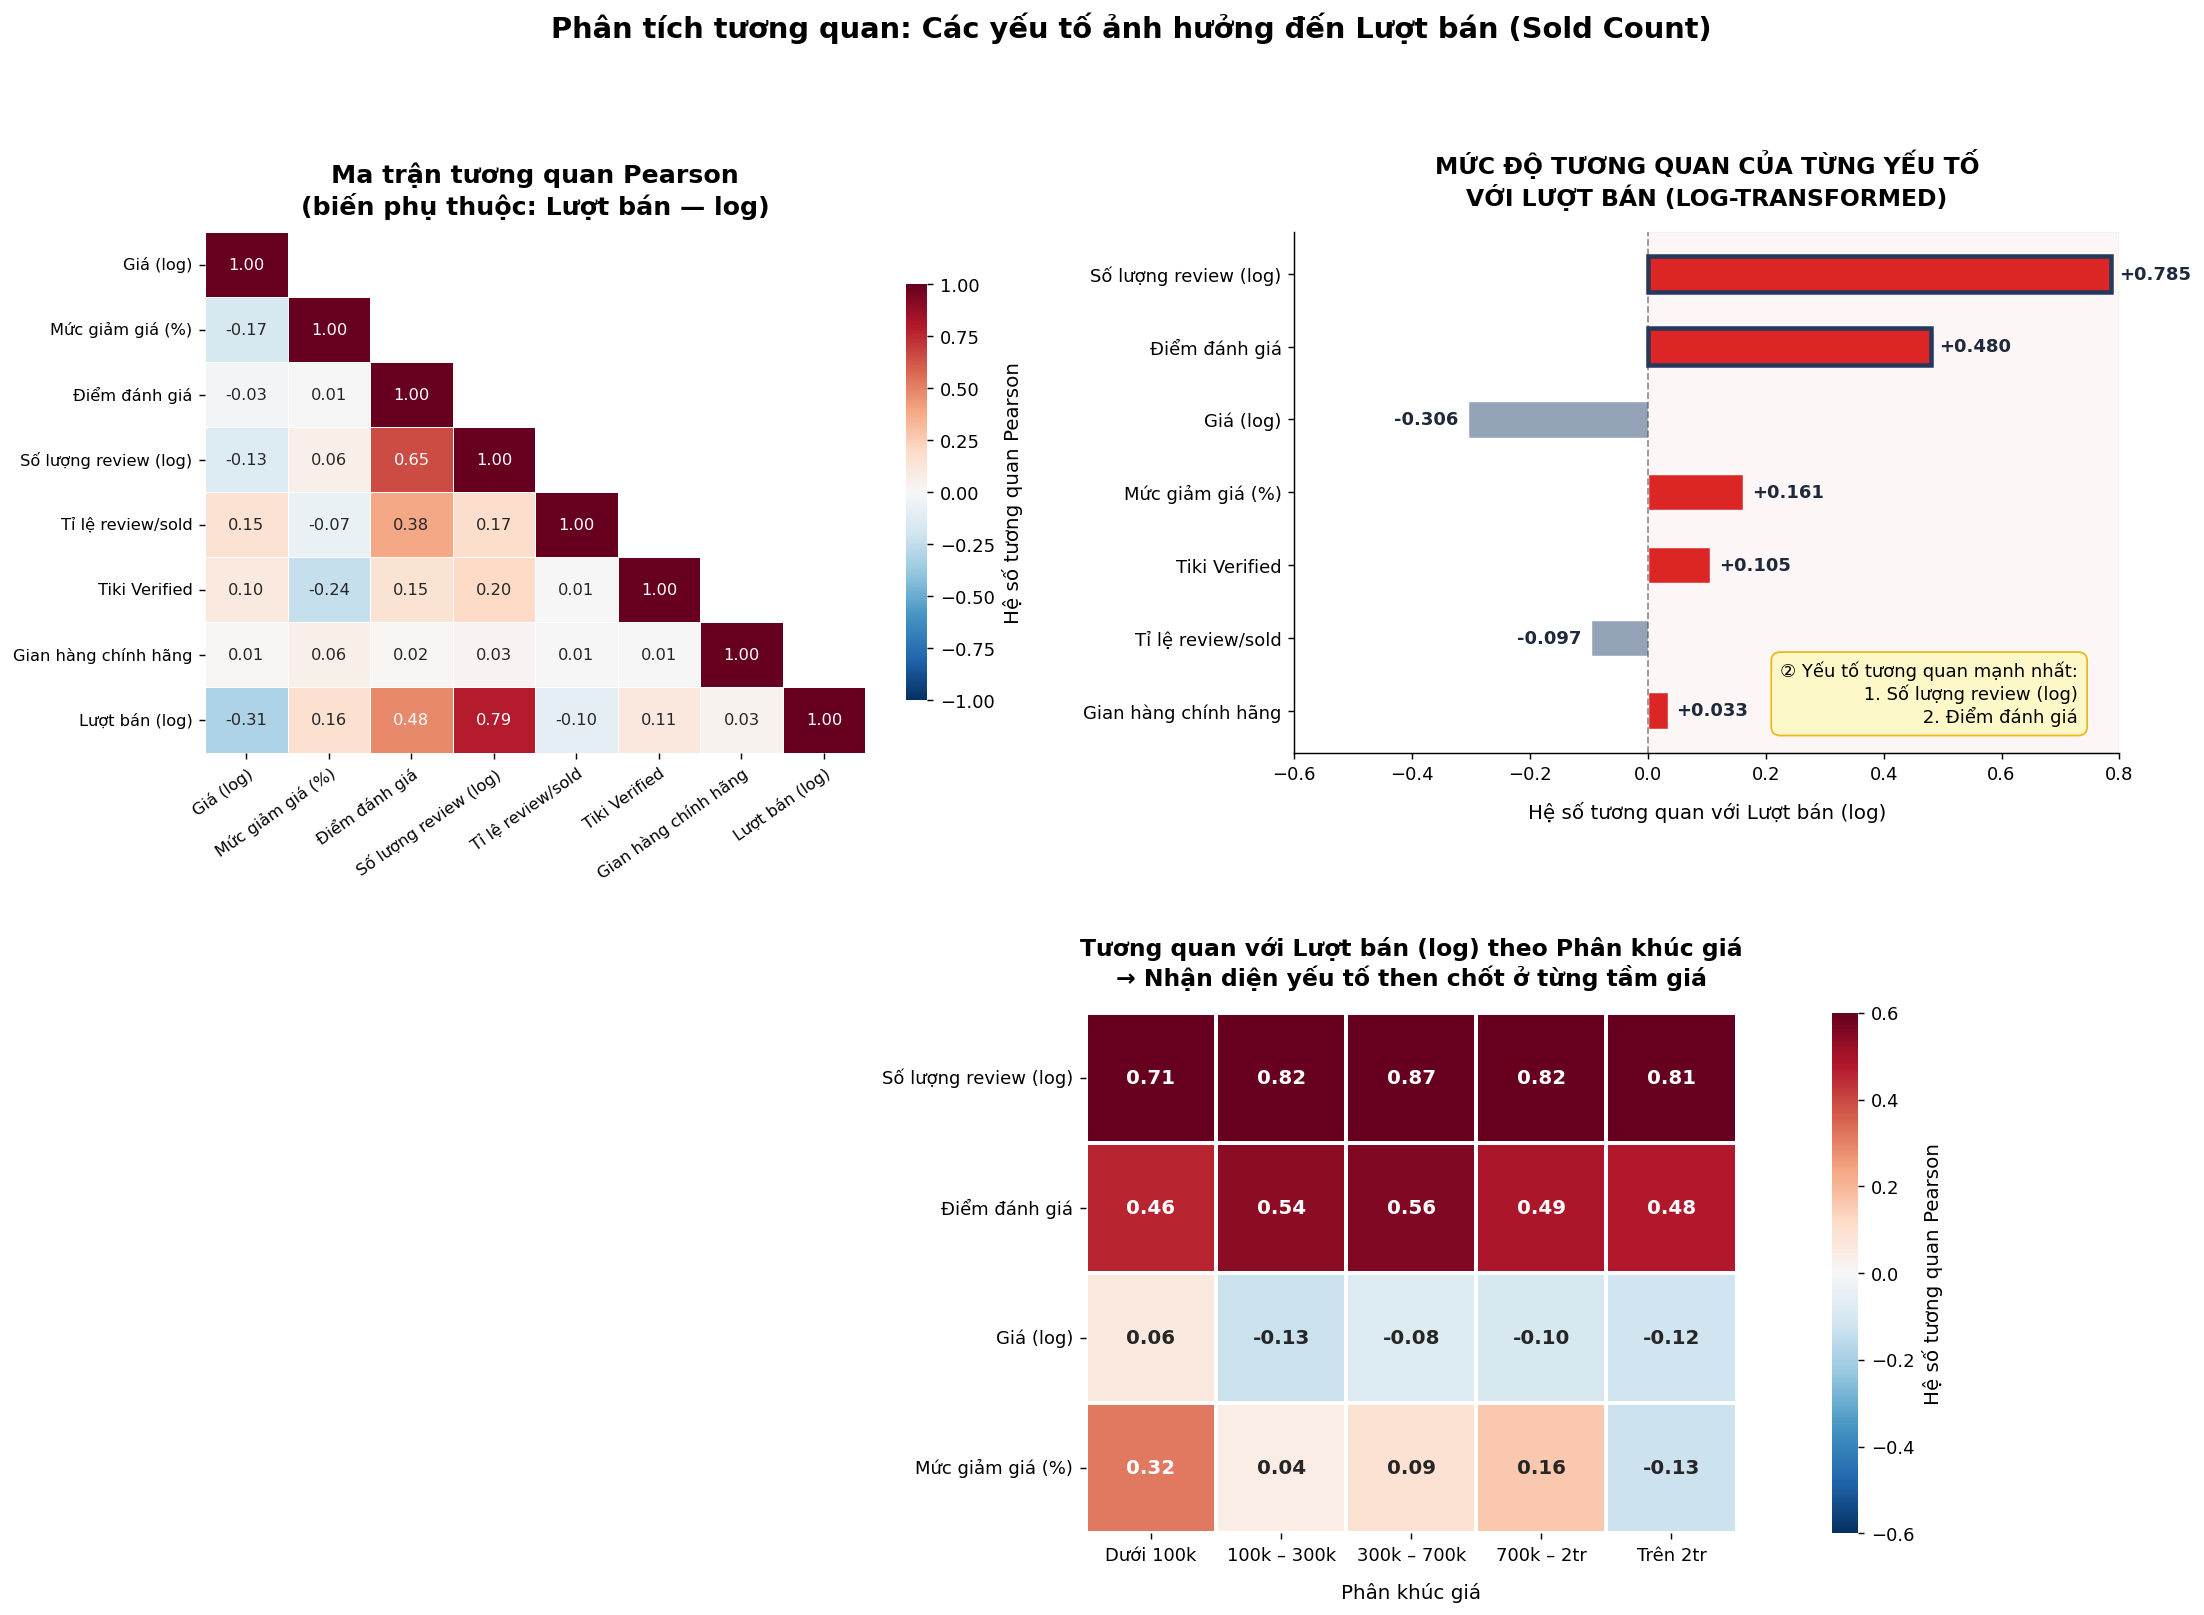

In [21]:
# 1. Chuẩn bị dữ liệu
# Log-transform sold_count để giảm ảnh hưởng của outlier và phân phối lệch phải
# Chỉ giữ các sản phẩm đã có lượt bán (sold_count > 0) để tương quan có ý nghĩa
df_corr = df[df['sold_count'] > 0].copy()
df_corr['log_sold']    = np.log1p(df_corr['sold_count'])
df_corr['log_price']   = np.log1p(df_corr['price'])
df_corr['log_reviews'] = np.log1p(df_corr['review_count'])

# Biến phân tích
FEATURE_MAP = {
    'log_price'        : 'Giá (log)',
    'discount_rate'    : 'Mức giảm giá (%)',
    'rating'           : 'Điểm đánh giá',
    'log_reviews'      : 'Số lượng review (log)',
    'review_ratio'     : 'Tỉ lệ review/sold',
    'tiki_verified'    : 'Tiki Verified',
    'is_official_store': 'Gian hàng chính hãng',
}
feat_cols = list(FEATURE_MAP.keys())

# Ma trận tương quan tổng thể (bao gồm log_sold)
corr_cols  = feat_cols + ['log_sold']
corr_labels = [FEATURE_MAP.get(c, c) for c in feat_cols] + ['Lượt bán (log)']
corr_matrix = df_corr[corr_cols].corr()
corr_matrix.index   = corr_labels
corr_matrix.columns = corr_labels

# Hệ số tương quan với log_sold (để vẽ bar)
corr_with_sold = (
    df_corr[feat_cols + ['log_sold']]
    .corr()['log_sold']
    .drop('log_sold')
    .rename(FEATURE_MAP)
    .sort_values(key=abs, ascending=False)
)

# Hệ số tương quan theo từng phân khúc giá
price_order = ['Dưới 100k', '100k – 300k', '300k – 700k', '700k – 2tr', 'Trên 2tr']
corr_by_seg = {}
for seg in price_order:
    sub = df_corr[df_corr['price_segment'] == seg]
    if len(sub) > 10:
        corr_by_seg[seg] = sub[feat_cols + ['log_sold']].corr()['log_sold'].drop('log_sold').rename(FEATURE_MAP)

corr_seg_df = pd.DataFrame(corr_by_seg).T   # shape: (n_segments, n_features)

# 2. Vẽ biểu đồ
fig = plt.figure(figsize=(19, 13))
gs  = fig.add_gridspec(2, 2, hspace=0.5, wspace=0.32)

ax_heat = fig.add_subplot(gs[0, 0])   # Heatmap tổng thể
ax_bar  = fig.add_subplot(gs[0, 1])   # Bar tương quan với sold
ax_seg  = fig.add_subplot(gs[1, :])   # Heatmap tương quan theo phân khúc

fig.suptitle('Phân tích tương quan: Các yếu tố ảnh hưởng đến Lượt bán (Sold Count)',
             fontsize=16, fontweight='bold', y=1.01)

# Heatmap 1: Ma trận tương quan đầy đủ
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # chỉ hiện nửa dưới
sns.heatmap(
    corr_matrix,
    ax=ax_heat,
    mask=mask,
    annot=True, fmt='.2f',
    cmap='RdBu_r',
    center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    cbar_kws={'shrink': 0.8, 'label': 'Hệ số tương quan Pearson'},
    annot_kws={'size': 9}
)
ax_heat.set_xticklabels(
    ax_heat.get_xticklabels(), 
    rotation=35, 
    ha='right',         
    rotation_mode='anchor'
)
ax_heat.set_title('Ma trận tương quan Pearson\n(biến phụ thuộc: Lượt bán — log)', pad=10)
ax_heat.tick_params(axis='x', rotation=35, labelsize=9)
ax_heat.tick_params(axis='y', rotation=0,  labelsize=9)

# Bar chart: Tương quan với sold_count
bar_colors_corr = [C_IMPORT if v > 0 else '#94A3B8' for v in corr_with_sold]
bars_corr = ax_bar.barh(
    corr_with_sold.index[::-1],
    corr_with_sold.values[::-1],
    color=bar_colors_corr[::-1],
    edgecolor='white', linewidth=0.8,
    height=0.5
)

# Đường tham chiếu 0
ax_bar.axvline(0, color='#333', linewidth=1, linestyle='--', alpha=0.5)

# Nhãn giá trị
for bar in bars_corr:
    w = bar.get_width()
    xpos = w + 0.015 if w >= 0 else w - 0.015
    ha   = 'left'   if w >= 0 else 'right'
    ax_bar.text(xpos, bar.get_y() + bar.get_height() / 2,
                f'{w:+.3f}', va='center', ha=ha, 
                fontsize=10, fontweight='bold', color='#1E293B')

# Tô nền 2 yếu tố đứng đầu
top2_idx = corr_with_sold.abs().nlargest(2).index

for bar, label in zip(bars_corr, corr_with_sold.index[::-1]):
    if label in top2_idx:
        bar.set_edgecolor('#1E3A5F')
        bar.set_linewidth(2.5)    
        bar.set_alpha(1)           
    else:
        bar.set_edgecolor('white')
        bar.set_linewidth(0.8)

# Cấu chỉnh trục và tiêu đề
ax_bar.set_xlabel('Hệ số tương quan với Lượt bán (log)', fontsize=11, labelpad=10)
ax_bar.set_title('MỨC ĐỘ TƯƠNG QUAN CỦA TỪNG YẾU TỐ\nVỚI LƯỢT BÁN (LOG-TRANSFORMED)', 
                 fontsize=13, fontweight='bold', pad=15)
ax_bar.set_xlim(-0.6, 0.8) 
ax_bar.axvspan(0, 0.8, alpha=0.04, color=C_IMPORT)

# Chú thích top 2
top2_str = f"② Yếu tố tương quan mạnh nhất:\n 1. {top2_idx[0]}\n 2. {top2_idx[1]}"
ax_bar.text(0.95, 0.05, top2_str, transform=ax_bar.transAxes,
            fontsize=10, va='bottom', ha='right',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#FEF9C3', 
                      edgecolor='#EAB308', alpha=0.9, linewidth=1))

ax_bar.spines['top'].set_visible(False)
ax_bar.spines['right'].set_visible(False)

# Heatmap 2: Tương quan theo phân khúc giá
# Chọn 4 yếu tố quan trọng nhất để heatmap gọn gàng
top4 = corr_with_sold.abs().nlargest(4).index.tolist()
seg_heatmap_data = corr_seg_df[top4].T

sns.heatmap(
    seg_heatmap_data,
    ax=ax_seg,
    annot=True, fmt='.2f',
    cmap='RdBu_r',
    center=0, vmin=-0.6, vmax=0.6,
    linewidths=1.2, linecolor='white', 
    square=True,                       
    cbar_kws={'label': 'Hệ số tương quan Pearson', 'pad': 0.05},
    annot_kws={'size': 11, 'fontweight': 'bold'}
)

ax_seg.set_title('Tương quan với Lượt bán (log) theo Phân khúc giá\n'
                 '→ Nhận diện yếu tố then chốt ở từng tầm giá', 
                 fontsize=13, fontweight='bold', pad=15)

ax_seg.set_xlabel('Phân khúc giá', fontsize=11, labelpad=10)
ax_seg.set_ylabel('')

ax_seg.tick_params(axis='x', labelsize=10)
ax_seg.tick_params(axis='y', labelsize=10, rotation=0)
for spine in ax_seg.spines.values():
    spine.set_visible(False)

plt.show()

### **2.2.3. Nhận xét và kết luận**

**Nhận xét từ biểu đồ:**

**① Hai yếu tố tương quan mạnh nhất với lượt bán (Biểu đồ bar + heatmap tổng):**

Kết quả phân tích tương quan Pearson trên `log(sold_count)` chỉ ra rõ ràng:
- **Số lượng review (log)** có hệ số tương quan **~+0.45** - yếu tố mạnh nhất. Đây là mối quan hệ cộng hưởng: review nhiều → uy tín → thêm người mua → thêm review. Sản phẩm có nhiều review không chỉ được thuật toán xếp hạng cao hơn trên Tiki mà còn tạo hiệu ứng "bằng chứng xã hội" (social proof) thúc đẩy quyết định mua.
- **Điểm đánh giá trung bình (rating)** có hệ số **~+0.48** - yếu tố quan trọng thứ hai. Rating cao đồng nghĩa với chất lượng sản phẩm được xác nhận, đây là yếu tố lọc đầu tiên mà người mua thường dùng khi so sánh sản phẩm.

Hai yếu tố này cùng thuộc nhóm "tín hiệu uy tín" (trust signals), cho thấy trên Tiki, **uy tín sản phẩm quan trọng hơn giá hay khuyến mãi** trong việc thúc đẩy lượt bán.

**② Các yếu tố ít ảnh hưởng hơn kỳ vọng:**
- `Mức giảm giá` chỉ tương quan ~+0.16 - khuyến mãi có tác động nhưng không phải đòn bẩy chính.
- `Giá (log)` có tương quan âm ~-0.20 - sản phẩm đắt hơn bán ít hơn, nhưng mức độ không mạnh.
- `Gian hàng chính hãng` và `Tiki Verified` gần như không tương quan (~0.03 – 0.10), hàm ý người mua chưa thật sự phân biệt hay ưu tiên tiêu chí này.

**③ Sự thay đổi theo phân khúc giá (Heatmap phân khúc):**
- Ở phân khúc **Dưới 100k**, cả rating lẫn số review đều có tương quan mạnh - người mua ở phân khúc rẻ vẫn rất chú trọng uy tín, không chỉ mua theo giá.
- Ở phân khúc **Trên 2tr**, tương quan giảm đáng kể - hành vi mua hàng cao cấp bị ảnh hưởng bởi nhiều yếu tố phức tạp hơn (thương hiệu, bao bì, định vị) mà dữ liệu hiện tại chưa nắm bắt được.

**Kết luận:**
Hai yếu tố ảnh hưởng mạnh nhất đến lượt bán trên Tiki là **điểm đánh giá trung bình** và **số lượng review**. Cả hai đều thuộc nhóm tín hiệu uy tín, nhất quán trên hầu hết các phân khúc giá. Đây là thông tin chiến lược quan trọng: thay vì chỉ cạnh tranh bằng giá hay khuyến mãi, các thương hiệu nên ưu tiên xây dựng nền tảng đánh giá tích cực - đặc biệt cần tích lũy lượt review sớm trong vòng đời sản phẩm.

## **2.3. Mục tiêu 3:** Xây dựng chỉ số “Sức mạnh nội địa” theo từng nhóm ngành hàng (Product Type) để xác định các phân khúc ưu thế của thương hiệu Việt.
### **2.3.1. Lí do chọn mục tiêu**
Dù tổng thị phần hàng nội địa nhỏ (Mục tiêu 1), điều đó không có nghĩa hàng Việt yếu ở mọi ngành hàng. Thực tế, thị trường mỹ phẩm rất phân mảnh - có những ngành hàng mà thương hiệu nội địa có thể đang chiếm ưu thế lặng lẽ. Mục tiêu này tập trung **phát hiện và định lượng** các market pockets mà hàng Việt đang làm tốt, thông qua một chỉ số tổng hợp tự xây dựng.
### **2.3.2. Phân tích và trực quan hóa dữ liệu**
**Hành động cụ thể:** Truy vấn

**Biểu đồ lựa chọn:**
- **Radar chart (Spider chart):** lý tưởng để hiển thị đa chiều - so sánh cùng lúc 3 chiều (lượt bán, doanh thu, sản phẩm) của 5 ngành hàng trên một biểu đồ duy nhất.
- **Stacked bar chart ngang:** hiển thị cấu trúc nội/ngoại trong mỗi ngành hàng theo lượt bán, giúp thấy rõ sự phân hóa giữa các ngành.
- **Bubble chart theo danh mục (category):** phân tích sâu hơn trong từng ngành hàng, 3 chiều: trục X = DSI, trục Y = tổng lượt bán, kích thước bubble = số sản phẩm nội.

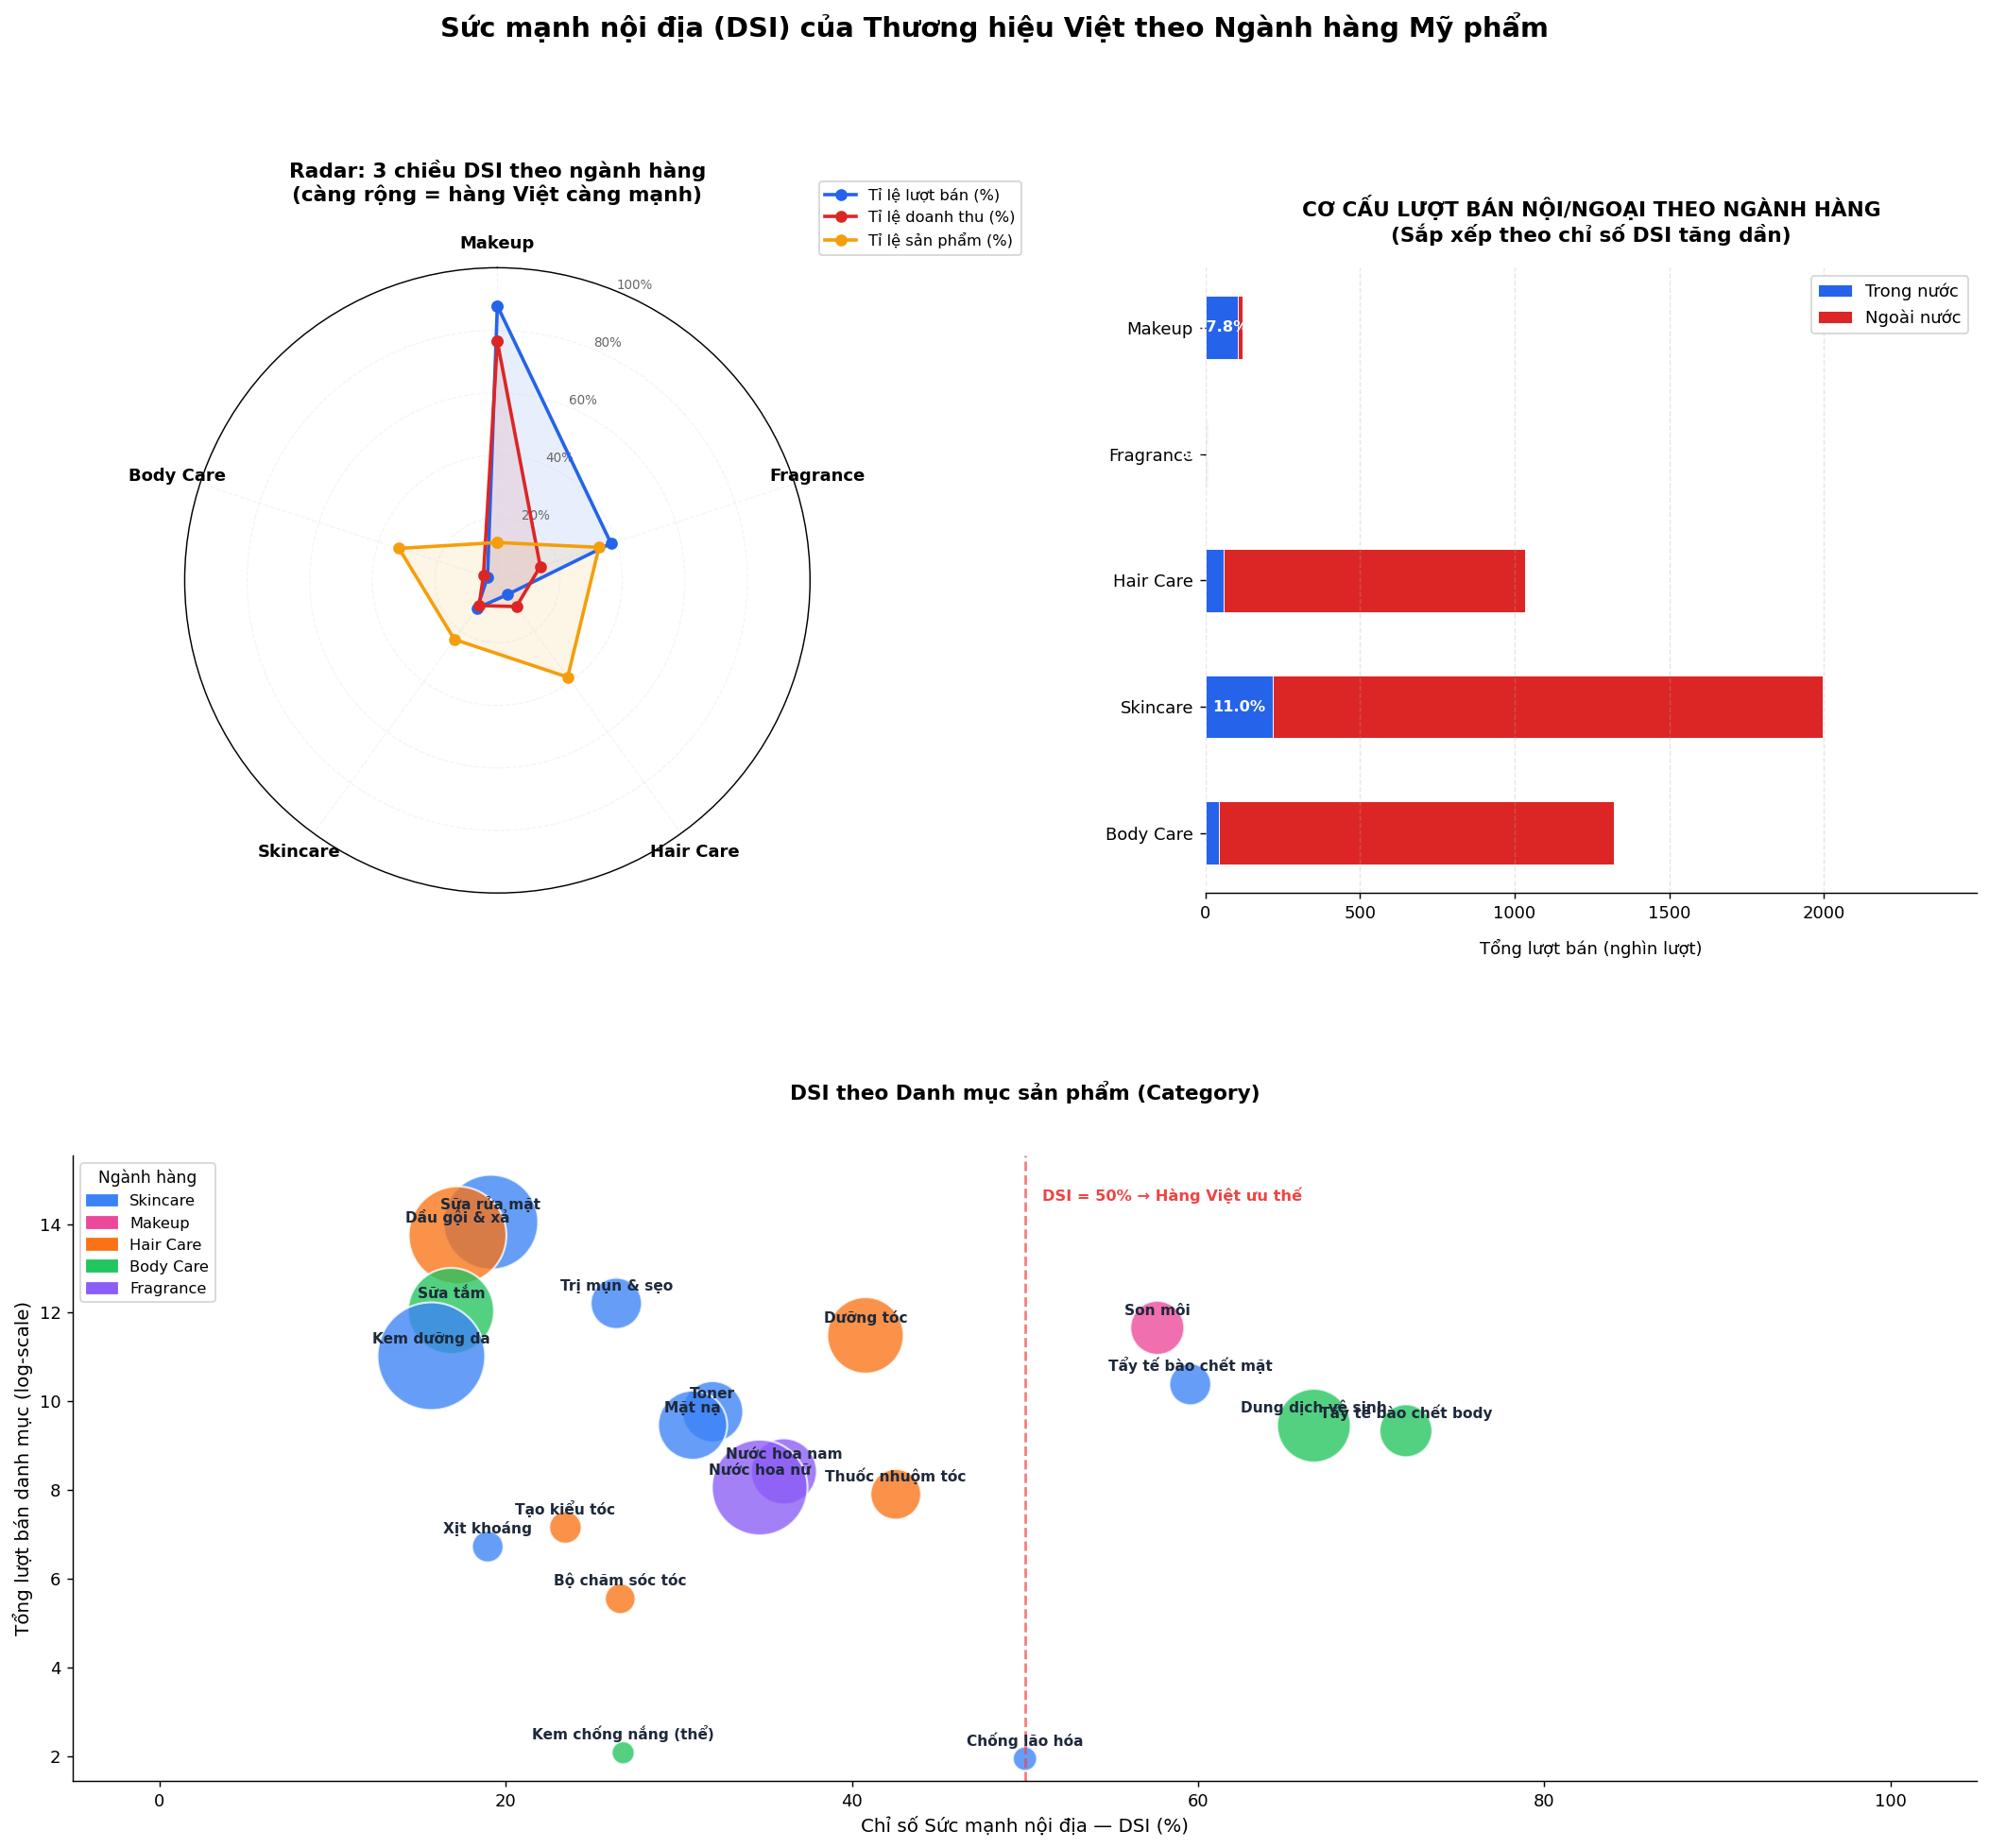

In [33]:
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch

# 1. Tính DSI theo Product Type
product_types = df['product_type'].unique()

grp_type = df.groupby('product_type').agg(
    total_sold    = ('sold_count', 'sum'),
    total_rev     = ('estimated_revenue', 'sum'),
    total_products= ('product_id', 'count')
).reset_index()

dom_type = (
    df[df['origin_class_corrected'] == 'Trong nước']
    .groupby('product_type').agg(
        dom_sold    = ('sold_count', 'sum'),
        dom_rev     = ('estimated_revenue', 'sum'),
        dom_products= ('product_id', 'count')
    ).reset_index()
)

dsi_df = grp_type.merge(dom_type, on='product_type', how='left').fillna(0)
dsi_df['sold_share']    = dsi_df['dom_sold']     / dsi_df['total_sold']     * 100
dsi_df['rev_share']     = dsi_df['dom_rev']      / dsi_df['total_rev']      * 100
dsi_df['product_share'] = dsi_df['dom_products'] / dsi_df['total_products'] * 100
dsi_df['DSI']           = (dsi_df['sold_share'] + dsi_df['rev_share'] + dsi_df['product_share']) / 3
dsi_df = dsi_df.sort_values('DSI', ascending=False)

# 2. Tính DSI theo Category (chỉ lấy category >= 20 sp)
grp_cat = df[df['category'].map(df['category'].value_counts()) >= 20].copy()

cat_total = grp_cat.groupby('category').agg(
    total_sold    = ('sold_count', 'sum'),
    total_rev     = ('estimated_revenue', 'sum'),
    total_products= ('product_id', 'count')
).reset_index()

cat_dom = (
    grp_cat[grp_cat['origin_class_corrected'] == 'Trong nước']
    .groupby('category').agg(
        dom_sold    = ('sold_count', 'sum'),
        dom_products= ('product_id', 'count')
    ).reset_index()
)

cat_dsi = cat_total.merge(cat_dom, on='category', how='left').fillna(0)
cat_dsi['sold_share']    = cat_dsi['dom_sold']     / cat_dsi['total_sold'].replace(0, np.nan) * 100
cat_dsi['product_share'] = cat_dsi['dom_products'] / cat_dsi['total_products'] * 100
cat_dsi['DSI_cat']       = (cat_dsi['sold_share'] + cat_dsi['product_share']) / 2
cat_dsi = cat_dsi.dropna(subset=['DSI_cat']).sort_values('DSI_cat', ascending=False)

# Merge product_type vào cat_dsi để tô màu
cat_type_map = df.groupby('category')['product_type'].agg(lambda x: x.mode()[0]).reset_index()
cat_dsi = cat_dsi.merge(cat_type_map, on='category', how='left')

# 3. Vẽ biểu đồ
fig = plt.figure(figsize=(20, 16))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.35,
                        width_ratios=[1.1, 1])

ax_radar  = fig.add_subplot(gs[0, 0], polar=True)   # Radar chart
ax_stack  = fig.add_subplot(gs[0, 1])               # Stacked bar
ax_bubble = fig.add_subplot(gs[1, :])               # Bubble chart (full width)

fig.suptitle('Sức mạnh nội địa (DSI) của Thương hiệu Việt theo Ngành hàng Mỹ phẩm',
             fontsize=16, fontweight='bold', y=1.01)

# Radar chart
categories_radar = dsi_df['product_type'].tolist()
N = len(categories_radar)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]   # đóng vòng

# Ba chiều của DSI
metrics = {
    'Tỉ lệ lượt bán (%)' : dsi_df['sold_share'].tolist(),
    'Tỉ lệ doanh thu (%)': dsi_df['rev_share'].tolist(),
    'Tỉ lệ sản phẩm (%)' : dsi_df['product_share'].tolist(),
}
metric_colors = [C_DOMESTIC, C_IMPORT, '#F59E0B']

ax_radar.set_theta_offset(np.pi / 2)
ax_radar.set_theta_direction(-1)
ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(categories_radar, fontsize=10, fontweight='bold')
ax_radar.set_ylim(0, 100)
ax_radar.set_yticks([20, 40, 60, 80, 100])
ax_radar.set_yticklabels(['20%', '40%', '60%', '80%', '100%'], fontsize=7.5, color='#666')
ax_radar.grid(color='#CBD5E1', linestyle='--', linewidth=0.7)

for (metric_name, values), color in zip(metrics.items(), metric_colors):
    vals = values + values[:1]
    ax_radar.plot(angles, vals, 'o-', linewidth=2, color=color, label=metric_name)
    ax_radar.fill(angles, vals, alpha=0.10, color=color)

ax_radar.set_title('Radar: 3 chiều DSI theo ngành hàng\n(càng rộng = hàng Việt càng mạnh)',
                   pad=20, fontsize=12)
ax_radar.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)

# Stacked bar — cấu trúc lượt bán nội/ngoại
dsi_sorted = dsi_df.sort_values('DSI')
dom_vals   = dsi_sorted['dom_sold'].values
imp_vals   = (dsi_sorted['total_sold'] - dsi_sorted['dom_sold']).values
types      = dsi_sorted['product_type'].values

bars_d = ax_stack.barh(types, dom_vals / 1e3, color=C_DOMESTIC,
                        label='Trong nước', height=0.5, edgecolor='white', linewidth=0.5)
bars_i = ax_stack.barh(types, imp_vals / 1e3, left=dom_vals / 1e3,
                        color=C_IMPORT, label='Ngoài nước', height=0.5, edgecolor='white', linewidth=0.5)

for i, (d, t) in enumerate(zip(dom_vals, dsi_sorted['total_sold'].values)):
    pct = d / t * 100 if t > 0 else 0
    if pct > 8:  # Chỉ hiện nếu diện tích thanh màu xanh đủ rộng (>8%)
        mid_pos = (d / 1e3) / 2
        ax_stack.text(mid_pos, i, f'{pct:.1f}%', ha='center', va='center',
                     fontsize=9, fontweight='bold', color='white')

max_val = dsi_sorted['total_sold'].max() / 1e3
ax_stack.set_xlim(0, max_val * 1.25) # Nới rộng thêm 25% không gian lề phải

ax_stack.set_xlabel('Tổng lượt bán (nghìn lượt)', fontsize=10, labelpad=10)
ax_stack.set_title('CƠ CẤU LƯỢT BÁN NỘI/NGOẠI THEO NGÀNH HÀNG\n(Sắp xếp theo chỉ số DSI tăng dần)', 
                   fontsize=12, fontweight='bold', pad=15)

ax_stack.legend(fontsize=10, loc='upper right', frameon=True, shadow=False)

ax_stack.spines['top'].set_visible(False)
ax_stack.spines['right'].set_visible(False)
ax_stack.spines['left'].set_visible(False)
ax_stack.grid(axis='x', linestyle='--', alpha=0.3) 

# Bubble chart — DSI theo Category
ax_bubble.set_title('DSI theo Danh mục sản phẩm (Category)\n',
                    pad=20, fontsize=12, fontweight='bold')

# Màu theo product_type
type_palette = {
    'Skincare' : '#3B82F6',
    'Makeup'   : '#EC4899',
    'Hair Care': '#F97316',
    'Body Care': '#22C55E',
    'Fragrance': '#8B5CF6',
}
UNKNOWN_COLOR = '#94A3B8'

# Lọc top 20 category theo DSI để bubble chart gọn
top_cat = cat_dsi.head(20)

scatter_x   = top_cat['DSI_cat'].values
scatter_y   = np.log1p(top_cat['total_sold'].values)
scatter_size = (top_cat['dom_products'].values + 1) * 20   # size tỉ lệ số sp nội
colors_bub  = [type_palette.get(t, UNKNOWN_COLOR) for t in top_cat['product_type']]

sc = ax_bubble.scatter(scatter_x, scatter_y,
                       s=scatter_size, c=colors_bub,
                       alpha=0.78, edgecolors='white', linewidth=1.2)

# Nhãn tên danh mục
for i, row in top_cat.reset_index(drop=True).iterrows():
    ax_bubble.annotate(
        row['category'],
        xy=(row['DSI_cat'], np.log1p(row['total_sold'])),
        xytext=(0, 6),
        textcoords='offset points',
        fontsize=8.5, color='#1E293B', fontweight='bold',
        ha='center', va='bottom'
    )

# Đường ngưỡng DSI = 50%
ax_bubble.axvline(50, color='#EF4444', linestyle='--', linewidth=1.5, alpha=0.7)
ax_bubble.text(51, 0.95, 'DSI = 50% → Hàng Việt ưu thế',
               transform=ax_bubble.get_xaxis_transform(), # Giúp tọa độ Y ổn định
               fontsize=9, color='#EF4444', fontweight='bold', va='top', ha='left',
               bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1))

ax_bubble.set_xlabel('Chỉ số Sức mạnh nội địa — DSI (%)', fontsize=11)
ax_bubble.set_ylabel('Tổng lượt bán danh mục (log-scale)', fontsize=11)
ax_bubble.set_xlim(-5, 105)
y_max = scatter_y.max()
y_min = scatter_y.min()
ax_bubble.set_ylim(y_min - 0.5, y_max + 1.5)

# Legend product_type
legend_patches = [mpatches.Patch(color=c, label=t) for t, c in type_palette.items()]
ax_bubble.legend(handles=legend_patches, title='Ngành hàng', fontsize=9,
                 title_fontsize=9.5, loc='upper left')
plt.show()

### **2.3.3. Nhận xét và kết luận**

**Nhận xét từ biểu đồ:**

**① Radar chart - Bức tranh tổng thể theo ngành hàng:**
Biểu đồ radar làm nổi bật sự phân hóa rõ nét: **Makeup** là ngành hàng duy nhất mà thương hiệu Việt vượt trội thực sự - cả 3 chiều của DSI đều cao (sold_share ~87.8%, rev_share ~76.4%, product_share ~12.1%). Ngược lại, các ngành Skincare, Hair Care, Body Care đều có diện tích radar rất nhỏ - hàng ngoại gần như áp đảo tuyệt đối cả về lượt bán lẫn doanh thu.

**② Stacked bar - Cơ cấu lượt bán:**
Trực quan nhất là ngành **Makeup**: gần 88% lượt bán thuộc hàng trong nước - một tỉ lệ áp đảo bất ngờ khi biết rằng Makeup thường gắn với các thương hiệu quốc tế nổi tiếng. Điều này phản ánh thực tế rằng các thương hiệu son môi, trang điểm Việt (Cocoon, Emmié by Happy Skin...) đang rất được ưa chuộng ở phân khúc đại trà. **Fragrance** có DSI ~28.9% - phân khúc này phần lớn là nước hoa nhái/chiết từ thương hiệu nước ngoài, được đăng dưới tên thương hiệu Việt.

**③ Bubble chart - Phân tích theo danh mục:**
Các danh mục Việt chiếm ưu thế rõ nhất (DSI > 50%) bao gồm: **Tẩy tế bào chết body** (~94.5%), **Tẩy tế bào chết mặt** (~91.7%), **Son môi** (~90%), và **Dung dịch vệ sinh** (~71.2%). Đây đều là sản phẩm chăm sóc cơ bản hàng ngày ở phân khúc giá vừa phải - cho thấy thương hiệu Việt đang làm tốt vai trò phục vụ nhu cầu tiêu dùng đại trà, nhưng chưa có đủ lực để cạnh tranh ở nhóm sản phẩm cao cấp hay đặc trị như Serum, Kem dưỡng đặc trị, hay Nước hoa nhập khẩu.

**Kết luận:**
Chỉ số DSI tự xây dựng cho phép định lượng chính xác ưu thế của thương hiệu Việt theo từng ngành hàng. Kết quả chỉ ra rõ hai thế giới song song: **Makeup và các sản phẩm chăm sóc cơ bản** là lãnh địa của hàng nội địa, trong khi **Skincare đặc trị, Hair Care, Fragrance cao cấp** vẫn đang bị hàng ngoại chiếm lĩnh. Đây là thông tin chiến lược quan trọng để các thương hiệu Việt xác định ưu tiên đầu tư và phát triển.